# 3.3 - Identificacao dos Maiores Credores - Viamao/RS (2019-2024)

**Fase 7** do roadmap ([`TAREFAS.md`](../TAREFAS.md)). Identifica os **maiores credores de 2024** pela **despesa paga**, mede a **concentracao** dos pagamentos e a **recorrencia** de fornecedores entre 2022-2024.

**Notas tecnicas (requisitos):**
- Variavel: `vl_pagamento` - filtro `tipo_operacao == "P"` (Pagamento).
- Agrupamento: por credor, chave estavel **`cd_credor`** (codigo do credor no TCE-RS; 0 nulos). O *nome* varia em caixa/grafia entre anos - mesma logica de harmonizacao das Secoes 3.1/3.2; o CNPJ/CPF vem do registro (`cnpj_cpf`).
- **Tratamento de credores internos (P1):** a lista de "credores" mistura **fornecedores de mercado** (contratados) com **pagamentos intragovernamentais** que nao sao contratacao - folha de pessoal, previdencias (propria/estadual/federal), tributos, depositos judiciais e servico da divida. Esses sao **classificados e sinalizados** (nao apagados) para nao distorcer a analise de concentracao/recorrencia de *fornecedores*.
- Ano-base do ranking: **2024**; recorrencia cruzada com **2022 e 2023**.

**Perguntas a responder:** 3.3.a (quem sao / qual setor), 3.3.b (concentracao), 3.3.c (recorrencia a luz da ciencia economica).

Dados: **TCE-RS/SIAPC** (nao auditados pelo Tribunal). Elaboracao propria.

## Setup - imports, caminhos e estilo

Imports e constantes (P5). Caminhos relativos a raiz do projeto. Reusa a paleta e o formatador de R$ das Secoes 3.1/3.2 (as tres secoes formam um so sistema visual) e acrescenta um formatador de CNPJ/CPF com mascara.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

RAIZ_PROJETO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARQ_PARQUET = RAIZ_PROJETO / "dados" / "processed" / "viamao_despesa_consolidado.parquet"
DIR_TABELAS = RAIZ_PROJETO / "output" / "tabelas"
DIR_GRAFICOS = RAIZ_PROJETO / "output" / "graficos"
DIR_TABELAS.mkdir(parents=True, exist_ok=True)
DIR_GRAFICOS.mkdir(parents=True, exist_ok=True)

ANOS = list(range(2019, 2025))  # 2019..2024
ANO_BASE = 2024                 # ano-base do ranking de credores
FONTE = "Fonte: TCE-RS/SIAPC. Elaboracao propria."

# Paleta categorica colorblind-safe (mesma das Secoes 3.1/3.2) + cinza para 'Demais'.
PALETA = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7",
          "#e34948", "#e87ba4", "#eb6834"]
COR_DEMAIS = "#b6b4ad"
COR_INTERNO = "#898781"  # credores intragovernamentais no grafico
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})

def reais(v, casas=0):
    """Formata numero como R$ com separador de milhar (padrao brasileiro)."""
    if pd.isna(v):
        return "—"
    s = f"{v:,.{casas}f}".replace(",", "§").replace(".", ",").replace("§", ".")
    return f"R$ {s}"

def formata_doc(doc, tp_pessoa):
    """CNPJ (PJ, 14 digitos) ou CPF (PF, 11 digitos) com mascara. A fonte nao
    guarda zeros a esquerda, entao completamos ate o comprimento do tipo. Ausente -> travessao."""
    if pd.isna(doc) or str(doc).strip().lower() in ("", "nan", "none"):
        return "—"
    d = "".join(ch for ch in str(doc) if ch.isdigit())
    if not d:
        return "—"
    if tp_pessoa == "PF" or len(d) <= 11:
        d = d.zfill(11)
        return f"{d[:3]}.{d[3:6]}.{d[6:9]}-{d[9:]}"
    d = d.zfill(14)
    return f"{d[:2]}.{d[2:5]}.{d[5:8]}/{d[8:12]}-{d[12:]}"

print("Parquet:", ARQ_PARQUET.name)

Parquet: viamao_despesa_consolidado.parquet


## Carga e filtro de Pagamento

Carrega o consolidado e mantem apenas operacoes de **Pagamento** (`P`). Confere o **total pago por ano** contra a auditoria da Fase 3 (mesmo sanity check das Secoes 3.1/3.2 - garante que estamos sobre a mesma base). Aqui a variavel e `vl_pagamento` (nao `vl_liquidacao`).

In [2]:
df = pd.read_parquet(ARQ_PARQUET)
pag = df[df["tipo_operacao"] == "P"].copy()
print(f"Operacoes de pagamento: {len(pag):,} de {len(df):,} linhas totais")

TOTAL_PAG_AUDITORIA = {  # R$ - conferido no notebook 00_exploratorio (aba Metadados da auditoria)
    2019: 441_581_461.90, 2020: 526_196_573.05, 2021: 590_205_606.57,
    2022: 665_733_559.66, 2023: 662_235_805.44, 2024: 734_914_063.59,
}
tot_por_ano = pag.groupby("ano")["vl_pagamento"].sum()
for ano in ANOS:
    assert abs(tot_por_ano[ano] - TOTAL_PAG_AUDITORIA[ano]) < 0.01, f"{ano} nao bate!"
print("OK - total pago por ano confere com a auditoria (dif. < R$ 0,01).")
print(f"Total pago 2024: {reais(tot_por_ano[2024])}")
pag[["ano", "cd_credor", "nm_credor", "tp_pessoa", "cnpj_cpf", "vl_pagamento"]].head()

Operacoes de pagamento: 194,150 de 408,953 linhas totais
OK - total pago por ano confere com a auditoria (dif. < R$ 0,01).
Total pago 2024: R$ 734.914.064


,ano,cd_credor,nm_credor,tp_pessoa,cnpj_cpf,vl_pagamento
259,2019,3307,MECANICAPINA LIMPEZA URBANA LTDA,PJ,2207800000103,404739.36
260,2019,8784,FAGNER MAXIMIANO PESCH,PF,1216045003,25.82
261,2019,8784,FAGNER MAXIMIANO PESCH,PF,1216045003,1.77
262,2019,8784,FAGNER MAXIMIANO PESCH,PF,1216045003,225.90
263,2019,8850,SAMUEL MOISES FERREIRA DE SOUZA - ME,PJ,14991346000103,48000.00


## Chave do credor e harmonizacao do nome (P1 - transformacao documentada)

Como nas Secoes 3.1/3.2, a grafia do **nome** do credor varia entre anos; a chave estavel e o **codigo `cd_credor`** (sem nulos nos pagamentos). Agrupamos por `cd_credor` e rotulamos com o nome do **ano mais recente** em que o credor recebeu; o **CNPJ/CPF** e o ultimo valor nao nulo observado. Nenhum valor e criado.

In [3]:
# Nome canonico = grafia do ano mais recente em que cada cd_credor aparece.
ult = pag.sort_values("ano").groupby("cd_credor").tail(1)
nome_canonico = ult.set_index("cd_credor")["nm_credor"]
tp_canonico = ult.set_index("cd_credor")["tp_pessoa"]
# CNPJ/CPF: ultimo nao nulo (a fonte deixa ~36% dos pagamentos sem documento).
doc_canonico = (pag.dropna(subset=["cnpj_cpf"]).sort_values("ano")
                .groupby("cd_credor")["cnpj_cpf"].last())

n_cd = pag["cd_credor"].nunique()
n_nm = pag["nm_credor"].nunique()
print(f"Credores distintos por codigo (cd_credor): {n_cd:,} | por nome (nm_credor): {n_nm:,}")
print(f"cd_credor nulos nos pagamentos: {int(pag['cd_credor'].isna().sum())}")
print(f"Credores sem CNPJ/CPF registrado (documento ausente na fonte): "
      f"{n_cd - doc_canonico.index.nunique():,}")

Credores distintos por codigo (cd_credor): 6,578 | por nome (nm_credor): 6,588
cd_credor nulos nos pagamentos: 0
Credores sem CNPJ/CPF registrado (documento ausente na fonte): 59


## Classificacao: fornecedor de mercado vs. pagamento intragovernamental (P1)

O requisito pede **separar a Prefeitura / orgaos proprios dos fornecedores externos**. A lista de credores mistura duas naturezas muito diferentes:

- **Fornecedores de mercado** (o objeto da analise): empresas, cooperativas, OSCs e pessoas fisicas **contratadas** para entregar bens/servicos (obras, transporte, saude terceirizada, alimentacao escolar, limpeza urbana...).
- **Pagamentos intragovernamentais / nao-contratacao** (a sinalizar): **folha de pessoal**, **previdencias** (IPREV proprio, IPE-RS estadual, INSS federal), **empresa publica propria** (EPTV), **tributos** (Receita Federal, SEFAZ/RS), **depositos judiciais** (Poder Judiciario, TJ-RS, TRT-4, varas) e **servico da divida** (BRDE). Nao sao "credores contratados" - sao transferencias obrigatorias, encargos ou repasses internos.

**Decisao:** classificar explicitamente **por `cd_credor`** (lista fechada e justificada, nao busca por palavra no nome - evita falso-positivo do tipo "BANCO" dentro do nome de uma empresa). Os internos **permanecem na Tabela 3.3.A** (respondendo "maiores credores"), mas sao **excluidos** das metricas de concentracao/recorrencia de *fornecedores* (3.3.b/c). Abaixo do topo do ranking os valores intragovernamentais sao imateriais, entao a lista cobre os que efetivamente pesam.

In [4]:
# cd_credor -> (rotulo curto da categoria interna, motivo). Tudo que nao esta aqui = fornecedor de mercado.
CREDORES_INTERNOS = {
    "814":   ("Folha de pagamento",        "Pessoal/servidores - nao e contratacao de fornecedor"),
    "11310": ("Previdencia propria (IPREV)","Autarquia previdenciaria do proprio municipio (RPPS)"),
    "10699": ("Empresa publica propria (EPTV)","Empresa publica municipal de transito - repasse interno"),
    "122":   ("Previdencia federal (INSS)", "Contribuicao previdenciaria/encargo federal"),
    "306":   ("Previdencia estadual (IPE-RS)","Regime proprio estadual - encargo"),
    "13285": ("Tributo federal (Receita Federal)","Recolhimento de tributos/retencoes"),
    "304":   ("Tributo estadual (SEFAZ/RS)", "Recolhimento de tributos estaduais"),
    "252":   ("Deposito judicial (Poder Judiciario)","Consignacoes/depositos judiciais"),
    "6400":  ("Deposito judicial (TJ-RS)",   "Consignacoes/depositos judiciais"),
    "511":   ("Deposito judicial (TRT-4)",   "Consignacoes/depositos judiciais"),
    "7243":  ("Deposito judicial (Vara Civel Viamao)","Consignacoes/depositos judiciais"),
    "13755": ("Servico da divida (BRDE)",    "Amortizacao/juros de emprestimo - nao e fornecedor"),
}
COD_INTERNOS = set(CREDORES_INTERNOS)

def categoria(cd):
    return "Intragovernamental" if cd in COD_INTERNOS else "Fornecedor externo"

# Quanto do total pago de 2024 e intragovernamental vs fornecedores?
pag["categoria"] = pag["cd_credor"].map(categoria)
resumo_cat = (pag[pag["ano"] == 2024].groupby("categoria")["vl_pagamento"].sum()
              .sort_values(ascending=False))
tot24 = resumo_cat.sum()
print("Composicao do total pago em 2024 por natureza do credor:")
for c, v in resumo_cat.items():
    print(f"  {c:<20} {reais(v):>18}  ({v/tot24*100:5.1f}%)")
print("\nCredores intragovernamentais catalogados (cd_credor - rotulo):")
for cd in COD_INTERNOS:
    print(f"  {cd:>6} - {CREDORES_INTERNOS[cd][0]} ({nome_canonico.get(cd, '??')})")

Composicao do total pago em 2024 por natureza do credor:
  Intragovernamental       R$ 392.286.791  ( 53.4%)
  Fornecedor externo       R$ 342.627.272  ( 46.6%)

Credores intragovernamentais catalogados (cd_credor - rotulo):
     306 - Previdencia estadual (IPE-RS) (INSTITUTO DE PREVIDENCIA DO ESTADO DO RS)
   11310 - Previdencia propria (IPREV) (IPREV - INST DE PREVIDENCIA DOS SERV. DE VIAMAO)
   13285 - Tributo federal (Receita Federal) (SECRETARIA DA RECEITA FEDERAL)
    7243 - Deposito judicial (Vara Civel Viamao) (3A VARA CIVEL DA COMARCA DE VIAMAO)
    6400 - Deposito judicial (TJ-RS) (TRIBUNAL DE JUSTICA DO ESTADO DO RGS)
     252 - Deposito judicial (Poder Judiciario) (PODER JUDICIARIO)
   13755 - Servico da divida (BRDE) (BRDE - BANCO REGIONAL DE DESENV DO EXTREMO SUL)
     511 - Deposito judicial (TRT-4) (TRIBUNAL REGIONAL DO TRABALHO 4A REGIAO)
     304 - Tributo estadual (SEFAZ/RS) (SEFAZ/RS)
   10699 - Empresa publica propria (EPTV) (EPTV - EMPRESA PUBLICA DE TRANSITO DE V

## Tabela 3.3.A - Maiores credores de Viamao em 2024

Top 20 por **valor pago** em 2024, com **% do total** e **% acumulado** (leitura tipo curva de Lorenz - mostra concentracao). Coluna **Tipo** separa pessoa **juridica (PJ)** e **fisica (PF)**; coluna **Natureza** marca fornecedor de mercado vs. pagamento intragovernamental. O `%` e sempre sobre o **total pago do municipio** em 2024 (R$ 734,9 mi), inclusive a folha.

In [5]:
TOP_N = 20
p24 = pag[pag["ano"] == 2024]
tot_pago_24 = p24["vl_pagamento"].sum()

rank = (p24.groupby("cd_credor")["vl_pagamento"].sum()
        .sort_values(ascending=False).rename("pago").to_frame())
rank["Credor"] = rank.index.map(nome_canonico)
rank["Tipo"] = rank.index.map(tp_canonico)
rank["Natureza"] = rank.index.map(lambda cd: "Intragov." if cd in COD_INTERNOS else "Fornecedor")
rank["CNPJ/CPF"] = [formata_doc(doc_canonico.get(cd), tp_canonico.get(cd)) for cd in rank.index]
rank["% do total"] = rank["pago"] / tot_pago_24 * 100
rank["% acumulado"] = rank["% do total"].cumsum()

tab_a = rank.head(TOP_N).reset_index(drop=True).copy()
tab_a.insert(0, "Ranking", [str(i) for i in range(1, len(tab_a) + 1)])
tab_a = tab_a[["Ranking", "Credor", "CNPJ/CPF", "Tipo", "Natureza",
               "pago", "% do total", "% acumulado"]].rename(columns={"pago": "Valor pago (R$)"})

# Linha de total geral do municipio (todos os credores, nao so o Top 20).
tab_a.loc[len(tab_a)] = ["", "TOTAL GERAL PAGO (todos os credores)", "", "", "",
                         tot_pago_24, 100.0, 100.0]
print(f"Top 20 concentra {rank.head(TOP_N)['% do total'].sum():.1f}% do total pago de 2024.")
(tab_a.style
    .format({"Valor pago (R$)": reais, "% do total": "{:.2f}%", "% acumulado": "{:.2f}%"})
    .hide(axis="index")
    .set_caption("Tabela 3.3.A - Maiores credores de Viamao em 2024 (por despesa paga)"))

Top 20 concentra 76.7% do total pago de 2024.


Ranking,Credor,CNPJ/CPF,Tipo,Natureza,Valor pago (R$),% do total,% acumulado
1,FOLHA DE PAGAMENTO,—,PJ,Intragov.,R$ 294.142.044,40.02%,40.02%
2,IPREV - INST DE PREVIDENCIA DOS SERV. DE VIAMAO,31.384.511/0001-88,PJ,Intragov.,R$ 43.423.967,5.91%,45.93%
3,INSTITUTO SOCIO-EDUCACIONAL DA BIODIVERSIDADE - IN,09.345.122/0001-94,PJ,Fornecedor,R$ 36.880.134,5.02%,50.95%
4,PLUXEE BENEFICIOS BRASIL S.A.,69.034.668/0001-56,PJ,Fornecedor,R$ 32.838.272,4.47%,55.42%
5,ORGANIZACAO DA SOCIEDADE CIVIL IN SAUDE - INSTITUT,44.563.716/0001-72,PJ,Fornecedor,R$ 29.096.107,3.96%,59.38%
6,QFROTAS SISTEMAS LTDA,44.220.921/0001-35,PJ,Fornecedor,R$ 14.391.878,1.96%,61.34%
7,INSS INSTNACSEGDE SOCIAL,29.979.036/0001-40,PJ,Intragov.,R$ 11.050.043,1.50%,62.84%
8,CONSTRUMETAL INDUSTRIA E COMERCIO EIRELI - ME,09.312.981/0001-87,PJ,Fornecedor,R$ 10.784.346,1.47%,64.31%
9,INSTITUTO DE PREVIDENCIA DO ESTADO DO RS,92.829.100/0001-43,PJ,Intragov.,R$ 10.562.450,1.44%,65.74%
10,CRVR - RIOGRANDENSE VALORIZACAO DE RESIDUOS S.A.,03.505.185/0001-84,PJ,Fornecedor,R$ 9.991.471,1.36%,67.10%


## Concentracao dos pagamentos (subsidia 3.3.b)

Mede a concentracao de duas formas, para nao enganar:

1. **Sobre o total pago** (inclui folha e intragovernamentais): util para dimensionar o peso da **folha de pessoal**, que sozinha responde por ~40% de tudo que o municipio paga.
2. **Somente entre fornecedores de mercado** (exclui os intragovernamentais catalogados): e a medida correta de **concentracao de mercado / fornecedores**, que responde a pergunta 3.3.b.

In [6]:
def concentra(serie_valores, total):
    s = serie_valores.sort_values(ascending=False)
    return {
        "1 maior": s.iloc[0] / total * 100,
        "5 maiores": s.head(5).sum() / total * 100,
        "10 maiores": s.head(10).sum() / total * 100,
        "20 maiores": s.head(20).sum() / total * 100,
    }

pago_por_cd_24 = p24.groupby("cd_credor")["vl_pagamento"].sum()
externos_24 = pago_por_cd_24[[cd not in COD_INTERNOS for cd in pago_por_cd_24.index]]
tot_externos_24 = externos_24.sum()

conc = pd.DataFrame({
    "Sobre o total pago (%)": concentra(pago_por_cd_24, tot_pago_24),
    "Entre fornecedores de mercado (%)": concentra(externos_24, tot_externos_24),
})
print(f"Total pago 2024 .......... {reais(tot_pago_24)}")
print(f"So fornecedores de mercado {reais(tot_externos_24)} "
      f"({tot_externos_24/tot_pago_24*100:.1f}% do total; folha+intragov = o restante)")
print(f"Fornecedores de mercado distintos em 2024: {len(externos_24):,}")
conc.style.format("{:.1f}%").set_caption(
    "Concentracao dos pagamentos de 2024 (participacao acumulada dos maiores)")

Total pago 2024 .......... R$ 734.914.064
So fornecedores de mercado R$ 342.627.272 (46.6% do total; folha+intragov = o restante)
Fornecedores de mercado distintos em 2024: 2,355


,Sobre o total pago (%),Entre fornecedores de mercado (%)
1 maior,40.0%,10.8%
5 maiores,59.4%,36.2%
10 maiores,67.1%,48.6%
20 maiores,76.7%,62.4%


## Tabela 3.3.B - Fornecedores recorrentes (2022-2024)

Fornecedores de mercado que receberam pagamento **nos tres anos** (2022, 2023 e 2024) - o cruzamento que a professora pede para investigar contratacao repetida. Ordenado pelo **total pago no trienio**; intragovernamentais **excluidos** (o foco e contratacao). A ultima coluna traz a participacao de cada um no total pago a fornecedores em 2024.

In [7]:
TRIENIO = [2022, 2023, 2024]
pt = pag[pag["ano"].isin(TRIENIO)]
piv_rec = pt.pivot_table(index="cd_credor", columns="ano",
                         values="vl_pagamento", aggfunc="sum")
piv_rec = piv_rec.reindex(columns=TRIENIO)

# Recorrente = pagamento positivo nos 3 anos, e nao intragovernamental.
presente_3 = (piv_rec > 0).all(axis=1)
eh_externo = pd.Series({cd: cd not in COD_INTERNOS for cd in piv_rec.index})
rec_cds = piv_rec.index[presente_3 & eh_externo]

# Panorama: peso dos recorrentes no total pago a fornecedores de 2024.
externos_todos_24 = p24[[cd not in COD_INTERNOS for cd in p24["cd_credor"]]]
tot_forn_24 = externos_todos_24["vl_pagamento"].sum()
pago_rec_24 = externos_todos_24[externos_todos_24["cd_credor"].isin(rec_cds)]["vl_pagamento"].sum()
n_forn_trienio = int((eh_externo).sum())
print(f"Fornecedores recorrentes (pagos em 2022, 2023 e 2024): {len(rec_cds):,} "
      f"de {n_forn_trienio:,} fornecedores do trienio ({len(rec_cds)/n_forn_trienio*100:.1f}%)")
print(f"Eles concentram {pago_rec_24/tot_forn_24*100:.1f}% do pago a fornecedores em 2024.")

rec = piv_rec.loc[rec_cds].copy()
rec["Total trienio"] = rec.sum(axis=1)
rec = rec.sort_values("Total trienio", ascending=False)
tab_b = rec.head(15).copy()
tab_b.insert(0, "Credor", [nome_canonico.get(cd) for cd in tab_b.index])
tab_b.insert(1, "CNPJ/CPF", [formata_doc(doc_canonico.get(cd), tp_canonico.get(cd)) for cd in tab_b.index])
tab_b = tab_b.reset_index(drop=True).rename(
    columns={2022: "Pago 2022", 2023: "Pago 2023", 2024: "Pago 2024"})
(tab_b.style
    .format({c: reais for c in ["Pago 2022", "Pago 2023", "Pago 2024", "Total trienio"]})
    .hide(axis="index")
    .set_caption("Tabela 3.3.B - Top 15 fornecedores recorrentes 2022-2024 (por total pago no trienio)"))

Fornecedores recorrentes (pagos em 2022, 2023 e 2024): 404 de 4,590 fornecedores do trienio (8.8%)
Eles concentram 66.8% do pago a fornecedores em 2024.


Credor,CNPJ/CPF,Pago 2022,Pago 2023,Pago 2024,Total trienio
INSTITUTO SOCIO-EDUCACIONAL DA BIODIVERSIDADE - IN,09.345.122/0001-94,R$ 23.277.027,R$ 25.989.337,R$ 36.880.134,R$ 86.146.498
PLUXEE BENEFICIOS BRASIL S.A.,69.034.668/0001-56,R$ 20.119.932,R$ 26.881.620,R$ 32.838.272,R$ 79.839.824
ORGANIZACAO DA SOCIEDADE CIVIL IN SAUDE - INSTITUT,44.563.716/0001-72,R$ 18.368.092,R$ 19.922.956,R$ 29.096.107,R$ 67.387.156
DCS-CL CONSTRUTORA E PAVIMENTADORA LTDA,95.258.174/0001-65,R$ 15.522.604,R$ 12.712.762,R$ 2.465.576,R$ 30.700.943
CONSTRUMETAL INDUSTRIA E COMERCIO EIRELI - ME,09.312.981/0001-87,R$ 14.089.481,R$ 4.158.109,R$ 10.784.346,R$ 29.031.935
VIGILLARE SISTEMAS DE MONITORAMENTO LTDA,02.883.607/0001-92,R$ 4.062.253,R$ 9.732.077,R$ 9.785.500,R$ 23.579.830
COLETURB SOLUCOES AMBIENTAIS LTDA,21.145.485/0001-81,R$ 6.195.796,R$ 6.845.747,R$ 8.533.556,R$ 21.575.098
SAO JOAO COMERCIO E TRANSPORTE DE MINERAIS EIRELE,10.221.007/0001-97,R$ 7.107.097,R$ 6.944.808,R$ 6.838.565,R$ 20.890.470
OMEGA SERVICOS DE PORTARIA E LIMPEZA EIRELI,23.161.074/0001-05,R$ 6.164.370,R$ 7.867.276,R$ 5.556.654,R$ 19.588.301
PRIME CONSULTORIA E ASSESSORIA EMPRESARIAL LTDA,05.340.639/0001-30,R$ 8.832.144,R$ 9.554.902,R$ 1.083.188,R$ 19.470.234


## Grafico 3.3 - Concentracao dos Top 10 credores (2024)

Barras horizontais dos **10 maiores credores** de 2024 (maior no topo), com o **% do total pago** rotulado. Fornecedores de mercado em azul; pagamentos intragovernamentais em cinza (folha, previdencias, tributos, Judiciario). Uma barra final agrega **os demais ~2.350 credores**, deixando visivel o quanto o topo concentra.

Grafico salvo: output\graficos\3_3_concentracao_credores.png


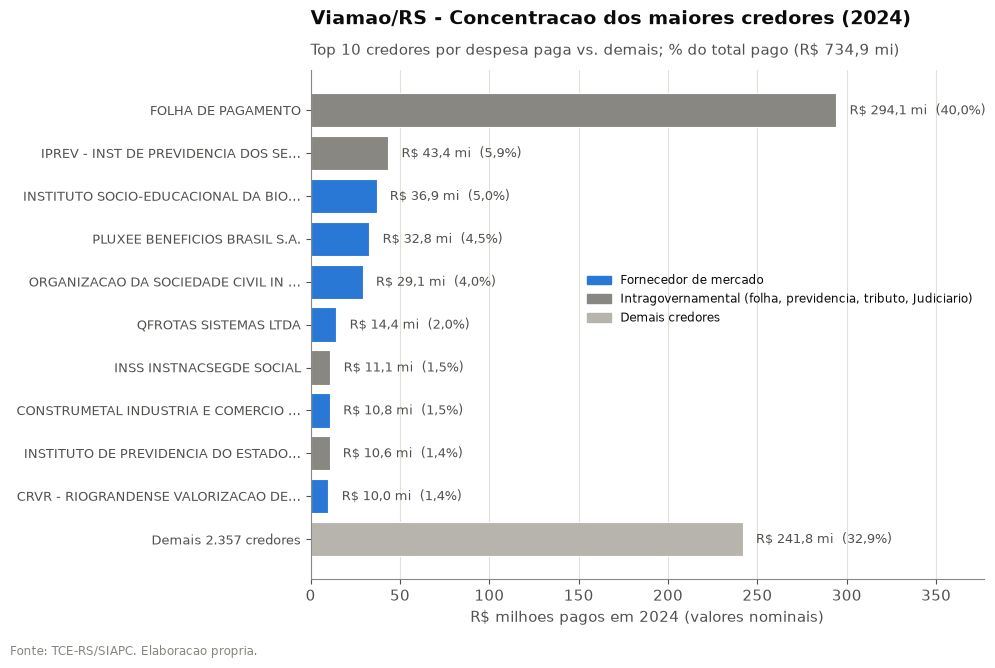

In [8]:
top10 = rank.head(10).copy()
labels = [nome_canonico.get(cd) for cd in top10.index]
# Encurta rotulos longos para caber no eixo.
labels = [(l[:34] + "…") if len(l) > 35 else l for l in labels]
vals = (top10["pago"] / 1e6).values
pcts = top10["% do total"].values
cores = [COR_INTERNO if cd in COD_INTERNOS else PALETA[0] for cd in top10.index]

# Barra 'Demais' (todos menos o Top 10).
demais_val = (tot_pago_24 - top10["pago"].sum()) / 1e6
demais_pct = 100 - top10["% do total"].sum()
n_demais = len(pago_por_cd_24) - 10

# Ordem no eixo (barh cresce para cima): maior no TOPO, 'Demais' agregado embaixo.
demais_label = f"Demais {n_demais:,} credores".replace(",", ".")
y_labels = [demais_label] + labels[::-1]
y_vals = [demais_val] + list(vals[::-1])
y_pcts = [demais_pct] + list(pcts[::-1])
y_cores = [COR_DEMAIS] + cores[::-1]
y = np.arange(len(y_labels))

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(y, y_vals, color=y_cores, edgecolor="white", linewidth=0.8)
for yi, (v, p) in enumerate(zip(y_vals, y_pcts)):
    txt = f"  R$ {v:.1f} mi  ({p:.1f}%)".replace(".", ",")  # decimal pt-BR
    ax.text(v + max(y_vals) * 0.01, yi, txt, va="center", ha="left", fontsize=9, color=INK2)
ax.set_yticks(y)
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlim(0, max(y_vals) * 1.28)
ax.set_xlabel("R$ milhoes pagos em 2024 (valores nominais)")
ax.set_axisbelow(True)
ax.grid(axis="x", color=GRID, linewidth=0.8)

from matplotlib.patches import Patch
leg = [Patch(color=PALETA[0], label="Fornecedor de mercado"),
       Patch(color=COR_INTERNO, label="Intragovernamental (folha, previdencia, tributo, Judiciario)"),
       Patch(color=COR_DEMAIS, label="Demais credores")]
# Area vazia a direita das barras curtas do meio - nao colide com os rotulos.
ax.legend(handles=leg, frameon=False, fontsize=8.5,
          loc="center right", bbox_to_anchor=(1.0, 0.55))

ax.text(0, 1.09, "Viamao/RS - Concentracao dos maiores credores (2024)",
        transform=ax.transAxes, fontsize=14, fontweight="bold", color=INK)
ax.text(0, 1.03, "Top 10 credores por despesa paga vs. demais; % do total pago (R$ 734,9 mi)",
        transform=ax.transAxes, fontsize=10.5, color=INK2)
fig.text(0.01, -0.02, FONTE, fontsize=8.5, color=MUTED)
fig.tight_layout()
fig.subplots_adjust(top=0.88)
ARQ_PNG = DIR_GRAFICOS / "3_3_concentracao_credores.png"
fig.savefig(ARQ_PNG, dpi=300, bbox_inches="tight")
print("Grafico salvo:", ARQ_PNG.relative_to(RAIZ_PROJETO))
plt.show()

## Exportacao - `output/tabelas/3_3_maiores_credores_2024.xlsx`

Planilha com as tabelas 3.3.A e 3.3.B, a concentracao, a lista de credores internos classificados e uma aba de Metadados.

In [9]:
from datetime import datetime

ARQ_XLSX = DIR_TABELAS / "3_3_maiores_credores_2024.xlsx"
internos_doc = pd.DataFrame(
    [(cd, nome_canonico.get(cd, ""), CREDORES_INTERNOS[cd][0], CREDORES_INTERNOS[cd][1])
     for cd in COD_INTERNOS],
    columns=["cd_credor", "nome_no_dado", "categoria", "motivo"])

meta = pd.DataFrame([
    ("Municipio", "Viamao/RS (codigo TCE-RS 63000)"),
    ("Fonte", "TCE-RS / SIAPC - Dados Abertos (nao auditados pelo Tribunal)"),
    ("Secao", "3.3 - Identificacao dos maiores credores"),
    ("Variavel", "vl_pagamento (despesa paga)"),
    ("Filtro", "tipo_operacao == 'P' (Pagamento)"),
    ("Agrupamento", "cd_credor (chave estavel); rotulo = nome do ano mais recente; CNPJ/CPF = ultimo nao nulo"),
    ("Ano-base do ranking", "2024"),
    ("Recorrencia", "credores pagos em 2022, 2023 e 2024 (fornecedores; intragov. excluidos)"),
    ("Tratamento de internos", "12 cd_credor classificados como intragovernamentais (ver aba Credores_internos)"),
    ("Total pago 2024 (R$)", round(tot_pago_24, 2)),
    ("Pago a fornecedores 2024 (R$)", round(tot_externos_24, 2)),
    ("Fornecedores de mercado distintos 2024", int(len(externos_24))),
    ("Gerado por", "notebooks/33_credores.ipynb"),
    ("Gerado em", datetime.now().isoformat(timespec="seconds")),
], columns=["campo", "valor"])

with pd.ExcelWriter(ARQ_XLSX, engine="openpyxl") as w:
    tab_a.to_excel(w, sheet_name="3.3.A_top20_2024", index=False)
    tab_b.to_excel(w, sheet_name="3.3.B_recorrentes", index=False)
    conc.rename_axis("corte").to_excel(w, sheet_name="Concentracao")
    internos_doc.to_excel(w, sheet_name="Credores_internos", index=False)
    meta.to_excel(w, sheet_name="Metadados", index=False)
print("Tabelas exportadas:", ARQ_XLSX.relative_to(RAIZ_PROJETO))
print("Abas: 3.3.A_top20_2024, 3.3.B_recorrentes, Concentracao, Credores_internos, Metadados")

Tabelas exportadas: output\tabelas\3_3_maiores_credores_2024.xlsx
Abas: 3.3.A_top20_2024, 3.3.B_recorrentes, Concentracao, Credores_internos, Metadados


## Analise - respostas 3.3.a, 3.3.b e 3.3.c

> Numeros lidos das tabelas acima (TCE-RS/SIAPC). O texto final do trabalho e redigido a partir daqui.

### 3.3.a - Quem sao os maiores credores e de que setor
Um fato estrutural vem antes dos fornecedores: **mais da metade (53,4%) do que Viamao pagou em 2024 nao e contratacao de mercado** - e **folha de pessoal** (R$ 294,1 mi, ~40% sozinha) mais **encargos e transferencias obrigatorias** (previdencias IPREV/INSS/IPE-RS, tributos a Receita/SEFAZ, depositos judiciais, servico da divida no BRDE). Os **fornecedores de mercado** ficam com os outros **46,6%** (R$ 342,6 mi).

Entre os **fornecedores contratados**, o maior e o **Instituto Socio-Educacional da Biodiversidade** (R$ 36,9 mi, 5,0% do total pago) - uma **OSC de saude** que opera servicos terceirizados do SUS municipal, ao lado de **Organizacao da Sociedade Civil IN Saude** (R$ 29,1 mi) e **ADRA**. Vem em seguida **alimentacao/beneficios** (Pluxee/ex-Sodexo, R$ 32,8 mi), **gestao de frota** (QFrotas), **obras e pavimentacao** (Construmetal, Melque, DCS-CL, Construtora LF), **residuos e limpeza urbana** (CRVR, Coleturb, Omega) e **transporte coletivo** (Empresa de Transporte Coletivo Viamao). Os grandes contratos concentram-se em **saude terceirizada, alimentacao escolar, limpeza urbana, obras e transporte**.

### 3.3.b - Ha concentracao?
Sim, e forte no topo. **Sobre o total pago**, a folha sozinha e **40,0%**; os **5 maiores credores = 59,4%**, os **10 maiores = 67,1%** e o **Top 20 = 76,7%**. Isolando **so os fornecedores de mercado** (R$ 342,6 mi, **2.355 credores distintos**), o maior pesa **10,8%**, os **5 maiores = 36,2%**, os **10 maiores = 48,6%** e os **20 maiores = 62,4%** do pago a fornecedores. Ou seja: **cerca de 20 fornecedores ficam com quase dois tercos** e uma cauda longa de milhares de pequenos credores divide o restante. O `% acumulado` da Tabela 3.3.A desenha essa curva tipo Lorenz: **poucos credores, grande fatia**.

### 3.3.c - Ha recorrencia? Leitura economica
Sim, e a regra: **404 fornecedores foram pagos nos tres anos (2022-2024)** - apenas **8,8%** dos que aparecem no trienio, mas concentrando **~67% de tudo que se pagou a fornecedores em 2024**. Os grandes contratos de **saude terceirizada (institutos/OSCs), limpeza urbana, alimentacao e transporte** reaparecem ano apos ano (Tabela 3.3.B).

**Interpretacao a luz da ciencia economica** (a desenvolver no texto final):
- **Custos de transicao e economias de escala/aprendizado** podem justificar recontratar quem ja opera um servico continuado (hospital, coleta de lixo, merenda) - trocar de operador tem custo e risco. Isso e **eficiencia**, nao necessariamente captura.
- Mas recorrencia elevada em mercados de **poucos participantes** liga o alerta para **barreiras a entrada** e baixa contestabilidade (Baumol): se sempre concorrem os mesmos, o poder de mercado do incumbente cresce e o preco tende a se afastar do competitivo.
- No limite, recorrencia + concentracao e o ambiente tipico de **rent-seeking / captura do Estado** (Stigler, Tullock): fornecedores com relacao estavel podem investir em influencia em vez de eficiencia, e desenhos de edital podem restringir a concorrencia.
- **Ressalva de honestidade (P1):** os dados de pagamento **nao permitem** afirmar rent-seeking - mostram *padrao* (concentracao + recorrencia), nao *conduta*. A distincao entre "incumbente eficiente" e "captura" exige olhar os **processos licitatorios** (modalidade, nº de concorrentes, dispensas/inexigibilidades), fora do escopo destes dados. O que os dados sustentam: **o mercado de fornecedores de Viamao e concentrado e estavel**, condicao que *merece* escrutinio concorrencial.

### Observacoes de fronteira (P1)
- **`vl_pagamento` != despesa do exercicio:** pagamentos podem quitar empenhos de anos anteriores (restos a pagar), entao o ranking de "pagos em 2024" nao e o mesmo que "liquidado em 2024" - e o que a pergunta pede (maiores credores **pagos**).
- **CNPJ/CPF ausente em ~36%** dos pagamentos (a fonte nao guarda zeros a esquerda; documentado no ETL). Para os maiores credores o documento esta quase sempre presente; usamos `cd_credor` como chave para nao depender do CNPJ.

---
Fonte dos dados: **TCE-RS/SIAPC**. Elaboracao propria.